In [ ]:
# =========================
# 0) INSTALAÇÃO + PATCH NUMPY (Prophet)
# =========================
!pip install -q prophet==1.1.5 cmdstanpy==1.2.4
!pip install -q numpy==1.26.4
!pip install -q catboost lightgbm scipy

import numpy as np
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "int_"):
    np.int_ = np.int64
if not hasattr(np, "bool_"):
    np.bool_ = np.bool_


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 323.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 63.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.90 requires numpy>=2; python_vers

In [ ]:
!pip install --upgrade --force-reinstall numpy pandas


  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 108.4 MB/s eta 0:00:00
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 24.0 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.3
    Uninstalling tzdata-2025.3:
      Successfully uninstalled tzdata-2025.3
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: numpy
 

In [ ]:
!pip install numpy==1.26.4 pandas==2.2.2


  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 69.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.1
    Uninstalling numpy-2.4.1:
      Successfully uninstalled numpy-2.4.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ras

In [ ]:

# 1) CONFIGS + IMPORTS

DATA_PATH = "/content"
PARAMETRO_ALVO = "TPT-T"
COLUNA_TEMPO = "datetime"

TRAIN_SPLIT = 0.9
TEST_MIN_STEPS = 200

RESAMPLE = True
FREQUENCIA = "D"
RESAMPLE_AGG = "median"

LAGS_CURTOS = [1, 2, 3, 6, 12]
LAGS_SAZONAIS = [24, 48, 72, 168]
ROLL_WINDOWS = [3, 6, 12, 24]

GERAR_GRAFICOS = True
SALVAR_RESULTADOS_CSV = False
RESULTS_CSV_PATH = "/mnt/data/resultados_comparacao_modelos_temp.csv"
RANDOM_STATE = 42

import os, glob, warnings, time, gc
warnings.filterwarnings("ignore")

import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from prophet import Prophet
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

from scipy.signal import savgol_filter

np.random.seed(RANDOM_STATE)


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:

# 2) MÉTRICAS

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    """
    MAPE robusto: ignora y_true ~ 0 e evita divisão por zero.
    """
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > eps)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + eps))) * 100.0


In [ ]:

# 3) OUTLIER FILTRO (HAMPEL)

def hampel_filter(series, window=21, n_sigmas=3):
    """
    Hampel filter (MAD). Substitui outliers pela mediana local.
    Bom para temperatura (remove spikes sem distorcer tendência).
    """
    s = series.copy()
    med = s.rolling(window, center=True).median()
    mad = (s - med).abs().rolling(window, center=True).median()
    thr = n_sigmas * 1.4826 * mad
    outliers = (s - med).abs() > thr
    s[outliers] = med[outliers]
    return s


In [ ]:

# 4) FEATURES (TIME + LAGS)

def add_time_features(df):
    out = df.copy()
    out["year"]  = out["ds"].dt.year
    out["month"] = out["ds"].dt.month
    out["day"]   = out["ds"].dt.day
    out["hour"]  = out["ds"].dt.hour
    out["dow"]   = out["ds"].dt.dayofweek
    out["week"]  = out["ds"].dt.isocalendar().week.astype(int)
    return out

def add_lag_features(df, lags, roll_windows):
    out = df.copy()
    for l in lags:
        out[f"lag_{l}"] = out["y"].shift(l)
    for w in roll_windows:
        out[f"rmean_{w}"] = out["y"].shift(1).rolling(w).mean()
        out[f"rstd_{w}"]  = out["y"].shift(1).rolling(w).std()
    return out


In [ ]:

# 5) LOADER (com resample + interpolação + outlier removal)

def carregar_serie(filepath, col_tempo, col_valor, do_resample=False, freq="D", agg="median"):
    df = pd.read_csv(filepath)

    # tenta achar coluna de valor se não existir
    if col_valor not in df.columns:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if col_tempo in num_cols:
            num_cols.remove(col_tempo)
        if len(num_cols) == 0:
            raise ValueError(f"No numeric columns found in {os.path.basename(filepath)}")
        print(f"[Warn] Column '{col_valor}' not found in {os.path.basename(filepath)}. Using '{num_cols[0]}'")
        col_valor = num_cols[0]

    # tenta achar coluna tempo se não existir
    if col_tempo not in df.columns:
        possiveis = [c for c in df.columns if any(k in c.lower() for k in ["time","date","datetime","timestamp","data"])]
        if not possiveis:
            raise ValueError(f"Could not identify a time column in {os.path.basename(filepath)}.")
        col_tempo = possiveis[0]
        print(f"[Warn] Using '{col_tempo}' as time column for {os.path.basename(filepath)}")

    df[col_tempo] = pd.to_datetime(df[col_tempo], errors="coerce")
    df = df.dropna(subset=[col_tempo])

    df = df[[col_tempo, col_valor]].dropna()
    df = df.rename(columns={col_tempo: "ds", col_valor: "y"})
    df = df.sort_values("ds").drop_duplicates(subset=["ds"])

    df = df.set_index("ds")

    # resample
    if do_resample:
        if agg == "mean":
            df = df.resample(freq).mean()
        elif agg == "sum":
            df = df.resample(freq).sum()
        else:
            df = df.resample(freq).median()

    # interpolação temporal
    df["y"] = df["y"].interpolate(method="time").bfill().ffill()

    # outlier removal (Hampel)
    df["y"] = hampel_filter(df["y"], window=21, n_sigmas=3)

    df = df.reset_index()
    df["y"] = df["y"].astype(float)
    return df


In [ ]:

# 6) TRAIN/TEST SPLIT

def split_train_test(df, train_split=0.9, test_min_steps=200):
    df = df.sort_values("ds").reset_index(drop=True)
    n = len(df)

    n_train = int(n * train_split)
    n_test = n - n_train

    if n_test < test_min_steps:
        n_test = test_min_steps
        n_train = n - n_test

    if n_train <= 0 or n_test <= 0:
        raise ValueError(f"Series too short: n={n}, n_train={n_train}, n_test={n_test}")

    train_df = df.iloc[:n_train].copy()
    test_df  = df.iloc[n_train:].copy()
    return train_df, test_df


In [ ]:

# 7) MODELOS: Prophet / Hybrid Prophet+LGBM / CatBoost

def fit_forecast_prophet(train_df, test_df):
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_mode="additive",
    )
    m.add_seasonality(name="monthly", period=30.5, fourier_order=6)
    m.add_seasonality(name="quarterly", period=90, fourier_order=4)
    m.fit(train_df[["ds","y"]], iter=2000)

    future = pd.DataFrame({"ds": test_df["ds"].values})
    fc = m.predict(future)
    return fc["yhat"].values

def fit_forecast_prophet_lgbm(train_df, test_df):
    # limita histórico para treinar Prophet rápido (opcional)
    if len(train_df) > 2000:
        train_df = train_df.iloc[-2000:].copy()

    mp = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.2,
        seasonality_mode="additive",
    )
    mp.add_seasonality(name="monthly", period=30.5, fourier_order=3)
    mp.fit(train_df[["ds","y"]], iter=1000)

    # resíduo no treino
    train_fc = mp.predict(train_df[["ds"]])
    train_resid = train_df.copy()
    train_resid["prophet_yhat"] = train_fc["yhat"].values
    train_resid["resid"] = train_resid["y"] - train_resid["prophet_yhat"]

    resid_df = add_time_features(train_resid)
    resid_df = add_lag_features(resid_df, LAGS_CURTOS + [24, 48, 72], [3, 6, 12])
    resid_df = resid_df.dropna().reset_index(drop=True)

    feats = [c for c in resid_df.columns if c not in ["ds","y","prophet_yhat","resid"]]
    X_train = resid_df[feats]
    y_train = resid_df["resid"]

    lgbm = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    )
    lgbm.fit(X_train, y_train)

    # Prophet no teste
    test_fc = mp.predict(test_df[["ds"]])
    prophet_yhat = test_fc["yhat"].values

    # features para prever resíduos no horizonte
    df_all = pd.concat([train_df[["ds","y"]], test_df[["ds"]]], ignore_index=True)
    df_all["y"] = df_all["y"].ffill()
    df_all = add_time_features(df_all)
    df_all = add_lag_features(df_all, LAGS_CURTOS + [24, 48, 72], [3,6,12])
    df_all = df_all.dropna().reset_index(drop=True)

    X_all = df_all[feats]
    resid_preds = lgbm.predict(X_all.iloc[-len(test_df):])

    return prophet_yhat + resid_preds

def fit_forecast_catboost(train_df, test_df):
    full = pd.concat([train_df.copy(), test_df.copy()], ignore_index=True)
    full = add_time_features(full)
    full = add_lag_features(full, LAGS_CURTOS + LAGS_SAZONAIS, ROLL_WINDOWS)

    n_train = len(train_df)
    train_block = full.iloc[:n_train].dropna().copy()

    feats = [c for c in train_block.columns if c not in ["ds","y"]]
    X_train = train_block[feats]
    y_train = train_block["y"]

    model = CatBoostRegressor(
        depth=10,
        learning_rate=0.02,
        n_estimators=1800,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        l2_leaf_reg=5,
        verbose=False
    )
    model.fit(X_train, y_train)

    preds = []
    for i in range(n_train, len(full)):
        hist = full.iloc[:i].copy()
        hist = add_time_features(hist)
        hist = add_lag_features(hist, LAGS_CURTOS + LAGS_SAZONAIS, ROLL_WINDOWS)
        last = hist.dropna().iloc[[-1]]

        if last.empty:
            pred = float(hist["y"].dropna().iloc[-1]) if hist["y"].notna().any() else float(y_train.iloc[-1])
        else:
            X_last = last[[c for c in last.columns if c not in ["ds","y"]]]
            pred = float(model.predict(X_last)[0])

        preds.append(pred)
        full.loc[i, "y"] = pred  # recursivo

    return np.array(preds)


In [ ]:

# 8) MODELOS: Linear + Wave (SavGol + extrapolação)

def fit_forecast_linear(train_df, test_df):
    X_train = np.arange(len(train_df)).reshape(-1, 1)
    y_train = train_df["y"].values

    model = LinearRegression()
    model.fit(X_train, y_train)

    X_test = np.arange(len(train_df), len(train_df) + len(test_df)).reshape(-1, 1)
    return model.predict(X_test)

def fit_forecast_wave(train_df, test_df, window=31, poly=2):
    y = train_df["y"].values

    # janela ímpar e válida
    if window >= len(y):
        window = len(y) - 1
    if window % 2 == 0:
        window -= 1
    window = max(window, 5)

    y_smooth = savgol_filter(y, window_length=window, polyorder=poly)

    X = np.arange(len(y_smooth)).reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y_smooth)

    X_test = np.arange(len(y), len(y) + len(test_df)).reshape(-1, 1)
    return model.predict(X_test)



🚀 STARTING WELL PROCESSING
Found 6 CSV file(s):
  - SPH-8.csv
  - SPH-2.csv
  - LL-11.csv
  - LL-22.csv
  - SPS-77.csv
  - SPH-6.csv

------------------------------------------------------------
🔹 [1/6] Processing well: SPH-8


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/n1oath2w.json


📈 Loaded series (1868 points). Splitting train/test...
⚙️  Running model 1/5 → Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/t7yzi0jw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39830', 'data', 'file=/tmp/tmpg8gju7b8/n1oath2w.json', 'init=/tmp/tmpg8gju7b8/t7yzi0jw.json', 'output', 'file=/tmp/tmpg8gju7b8/prophet_model2do_j52v/prophet_model-20260115153803.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
15:38:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:38:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/l255gskm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/ljo1nzre.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bi

✅ Prophet completed in 1.58 s
⚙️  Running model 2/5 → Hybrid (Prophet+LGBM)...


15:38:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3682
[LightGBM] [Info] Number of data points in the train set: 1596, number of used features: 19
[LightGBM] [Info] Start training from score 0.053676
✅ Hybrid completed in 2.70 s
⚙️  Running model 3/5 → CatBoost...
✅ CatBoost completed in 98.86 s
⚙️  Running model 4/5 → Linear...
✅ Linear completed in 0.03 s
⚙️  Running model 5/5 → Wave...
✅ Wave completed in 0.01 s


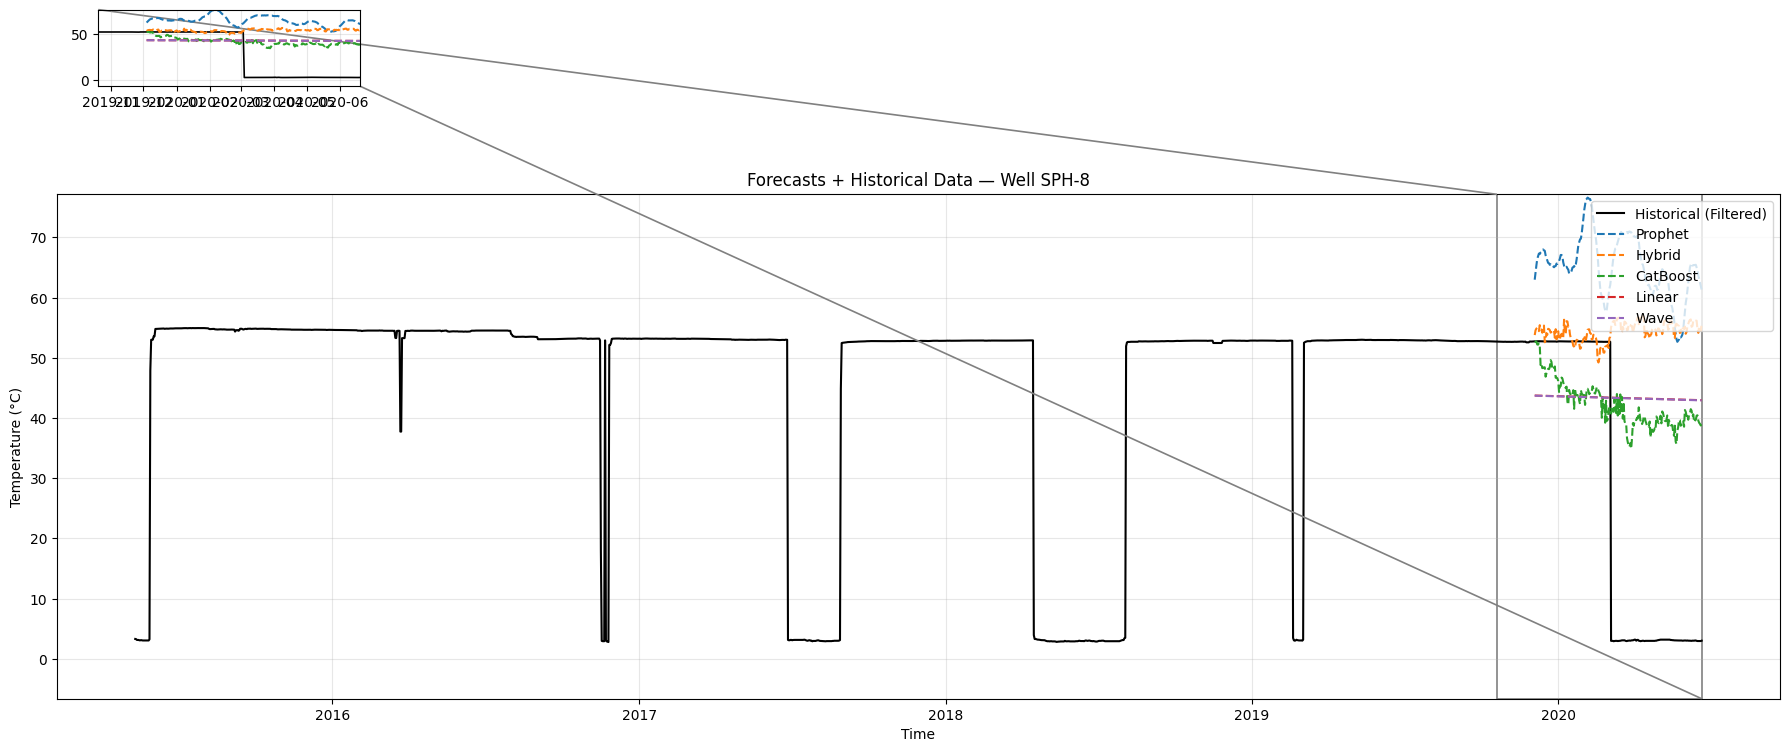

🕒 Well SPH-8 completed in 109.55 s

------------------------------------------------------------
🔹 [2/6] Processing well: SPH-2


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/w9sg66p0.json


📈 Loaded series (1827 points). Splitting train/test...
⚙️  Running model 1/5 → Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/qrmztlct.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5873', 'data', 'file=/tmp/tmpg8gju7b8/w9sg66p0.json', 'init=/tmp/tmpg8gju7b8/qrmztlct.json', 'output', 'file=/tmp/tmpg8gju7b8/prophet_model30c29hum/prophet_model-20260115153950.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
15:39:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:39:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/74l1fdm3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/6o6ad4rm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin

✅ Prophet completed in 1.19 s
⚙️  Running model 2/5 → Hybrid (Prophet+LGBM)...


15:39:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3682
[LightGBM] [Info] Number of data points in the train set: 1555, number of used features: 19
[LightGBM] [Info] Start training from score 0.381993
✅ Hybrid completed in 1.07 s
⚙️  Running model 3/5 → CatBoost...
✅ CatBoost completed in 99.84 s
⚙️  Running model 4/5 → Linear...
✅ Linear completed in 0.00 s
⚙️  Running model 5/5 → Wave...
✅ Wave completed in 0.00 s


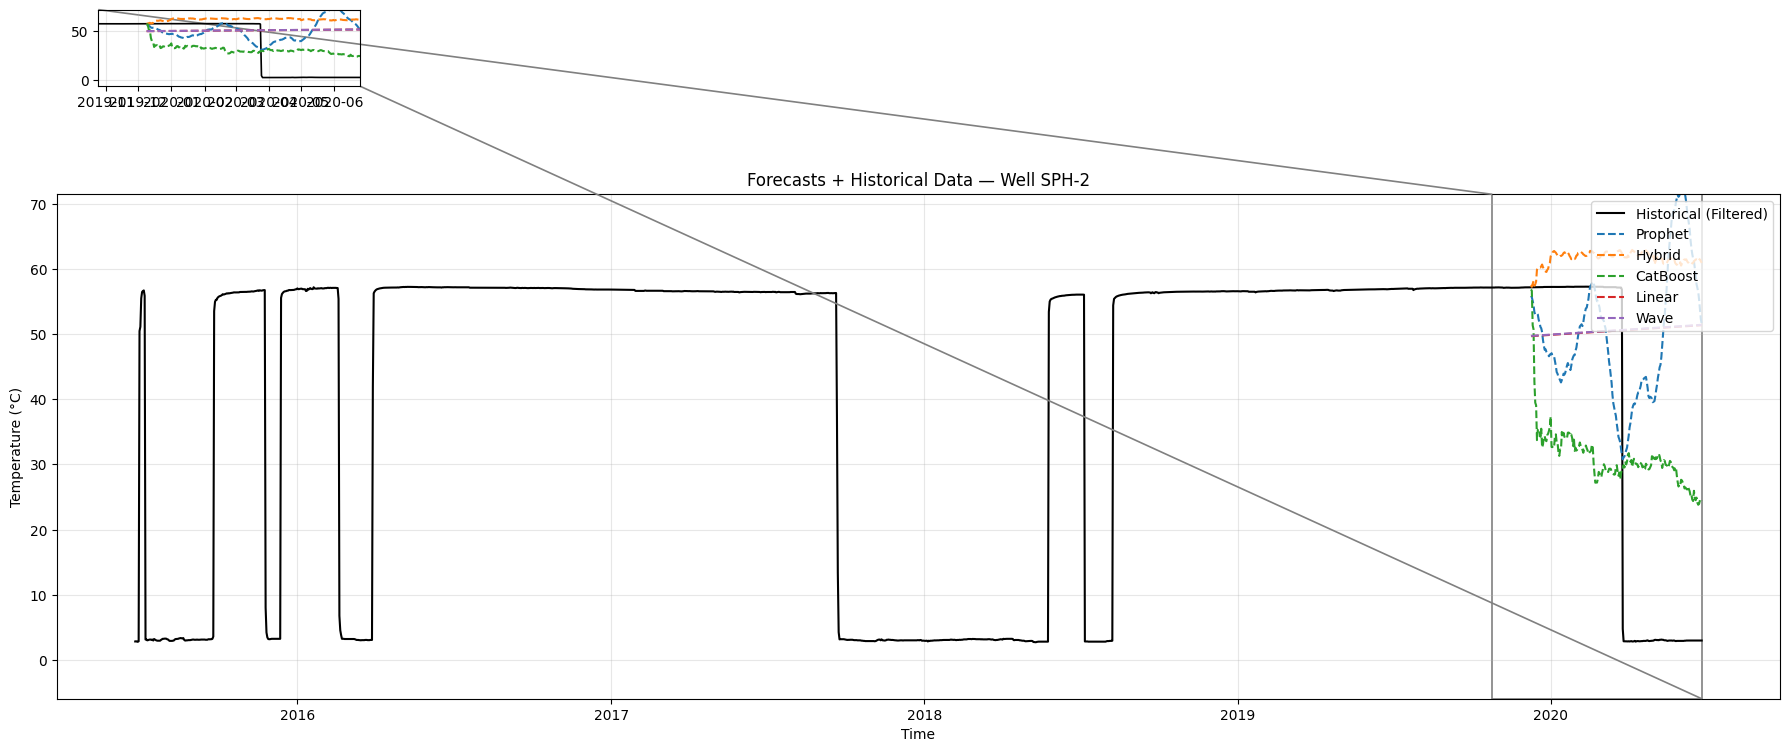

🕒 Well SPH-2 completed in 104.84 s

------------------------------------------------------------
🔹 [3/6] Processing well: LL-11


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/37x33e7v.json


📈 Loaded series (2587 points). Splitting train/test...
⚙️  Running model 1/5 → Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/35nvw3o2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=49497', 'data', 'file=/tmp/tmpg8gju7b8/37x33e7v.json', 'init=/tmp/tmpg8gju7b8/35nvw3o2.json', 'output', 'file=/tmp/tmpg8gju7b8/prophet_modelhgqw8mzl/prophet_model-20260115154135.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
15:41:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:41:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/495xdwrg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/84ugnodh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bi

✅ Prophet completed in 1.47 s
⚙️  Running model 2/5 → Hybrid (Prophet+LGBM)...


15:41:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3683
[LightGBM] [Info] Number of data points in the train set: 1928, number of used features: 19
[LightGBM] [Info] Start training from score 0.143904
✅ Hybrid completed in 1.38 s
⚙️  Running model 3/5 → CatBoost...
✅ CatBoost completed in 99.67 s
⚙️  Running model 4/5 → Linear...
✅ Linear completed in 0.00 s
⚙️  Running model 5/5 → Wave...
✅ Wave completed in 0.00 s


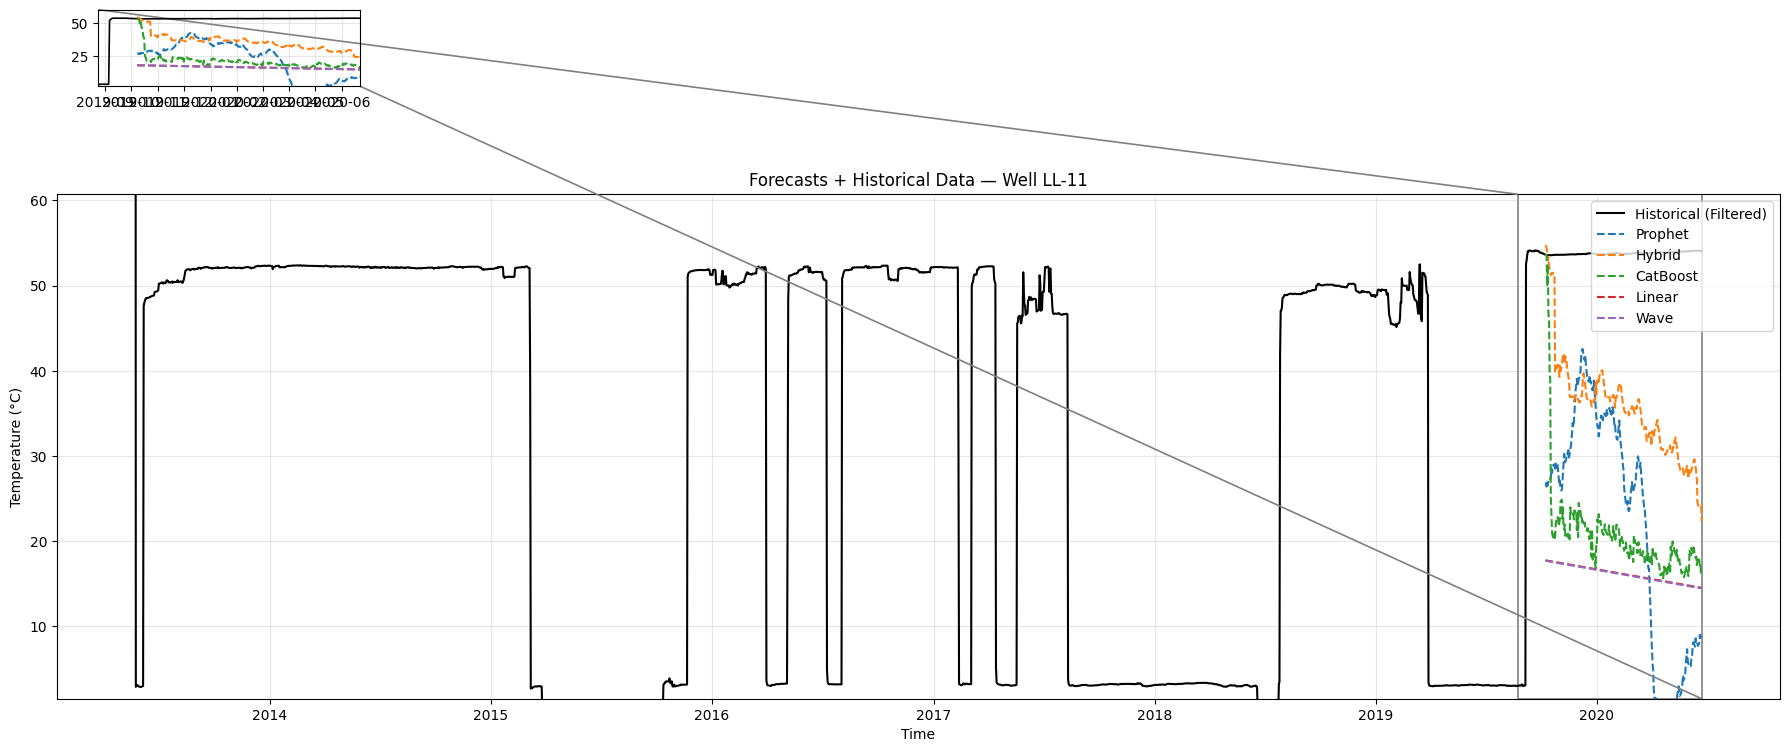

🕒 Well LL-11 completed in 105.72 s

------------------------------------------------------------
🔹 [4/6] Processing well: LL-22


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/4hmiwctw.json


📈 Loaded series (2259 points). Splitting train/test...
⚙️  Running model 1/5 → Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/1y13r3q0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=78957', 'data', 'file=/tmp/tmpg8gju7b8/4hmiwctw.json', 'init=/tmp/tmpg8gju7b8/1y13r3q0.json', 'output', 'file=/tmp/tmpg8gju7b8/prophet_modelk93o2p_1/prophet_model-20260115154320.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
15:43:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:43:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/3q73ppi2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/7v5rn8r9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bi

✅ Prophet completed in 0.62 s
⚙️  Running model 2/5 → Hybrid (Prophet+LGBM)...


15:43:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000497 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3683
[LightGBM] [Info] Number of data points in the train set: 1928, number of used features: 19
[LightGBM] [Info] Start training from score 0.025732
✅ Hybrid completed in 1.23 s
⚙️  Running model 3/5 → CatBoost...
✅ CatBoost completed in 101.34 s
⚙️  Running model 4/5 → Linear...
✅ Linear completed in 0.00 s
⚙️  Running model 5/5 → Wave...
✅ Wave completed in 0.00 s


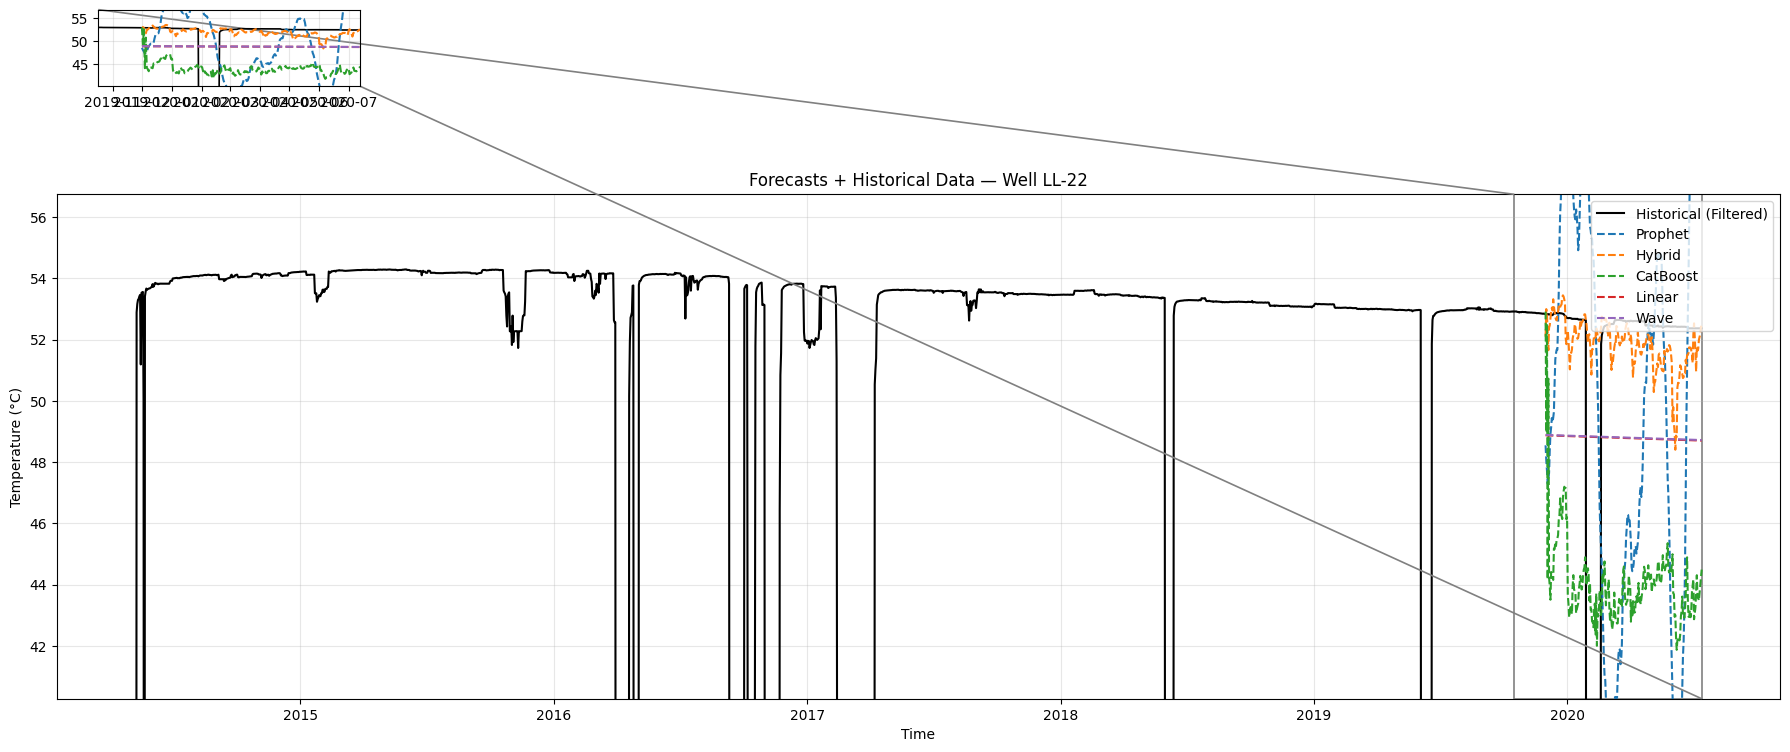

🕒 Well LL-22 completed in 105.62 s

------------------------------------------------------------
🔹 [5/6] Processing well: SPS-77


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/v97hnxie.json


📈 Loaded series (2325 points). Splitting train/test...
⚙️  Running model 1/5 → Prophet...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/n8l1yegb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75185', 'data', 'file=/tmp/tmpg8gju7b8/v97hnxie.json', 'init=/tmp/tmpg8gju7b8/n8l1yegb.json', 'output', 'file=/tmp/tmpg8gju7b8/prophet_model8fmet4nc/prophet_model-20260115154506.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
15:45:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:45:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/51ssw3he.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/akvl5rki.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bi

✅ Prophet completed in 1.09 s
⚙️  Running model 2/5 → Hybrid (Prophet+LGBM)...


15:45:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3683
[LightGBM] [Info] Number of data points in the train set: 1928, number of used features: 19
[LightGBM] [Info] Start training from score 0.073390
✅ Hybrid completed in 1.79 s
⚙️  Running model 3/5 → CatBoost...
✅ CatBoost completed in 98.43 s
⚙️  Running model 4/5 → Linear...
✅ Linear completed in 0.00 s
⚙️  Running model 5/5 → Wave...
✅ Wave completed in 0.00 s


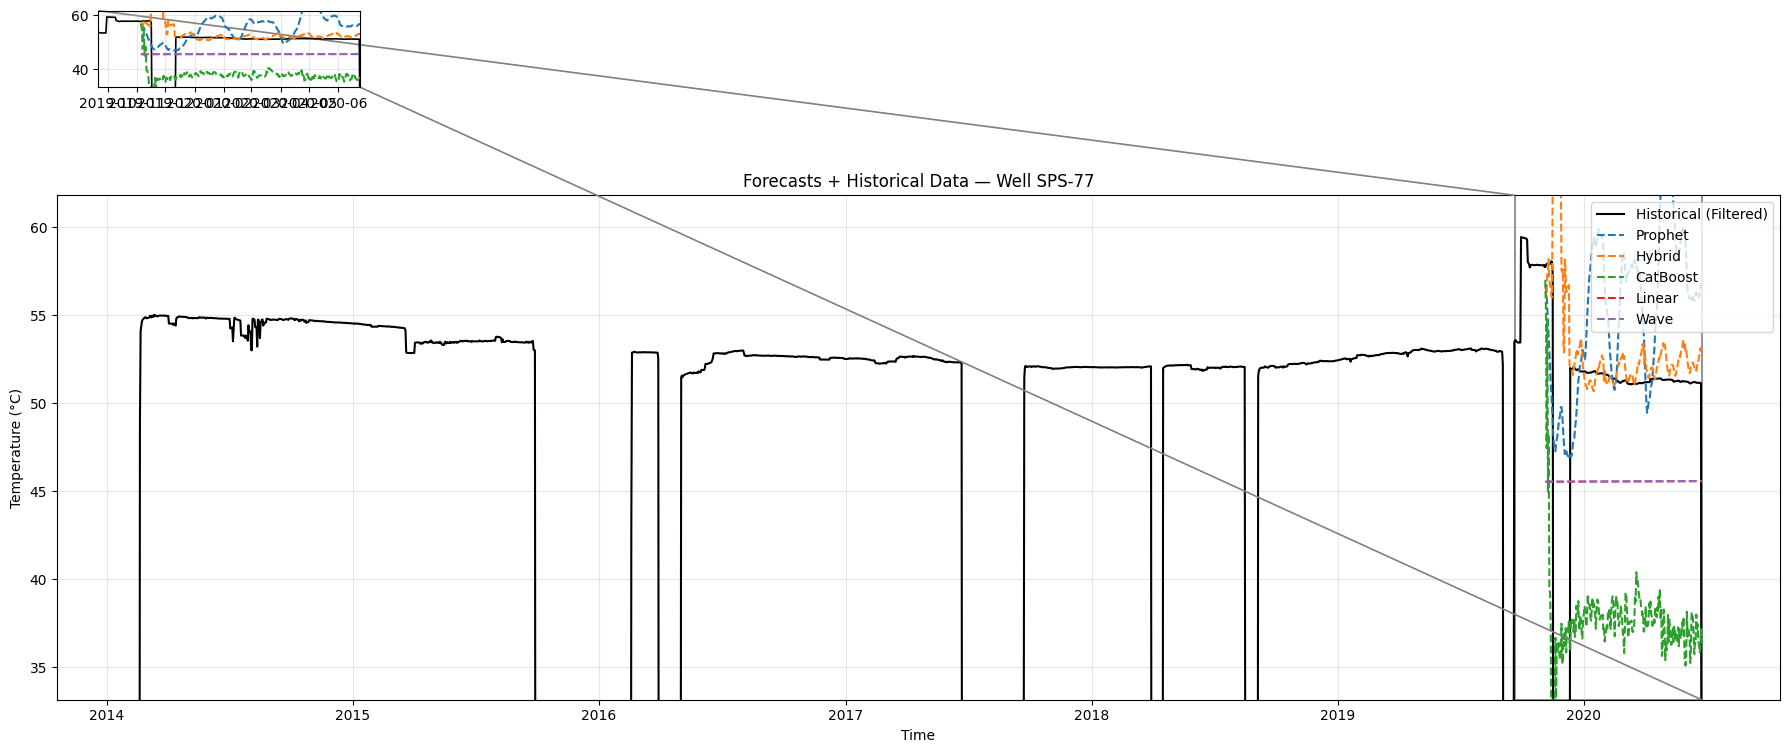

🕒 Well SPS-77 completed in 104.91 s

------------------------------------------------------------
🔹 [6/6] Processing well: SPH-6


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/sqi5bffz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/_ejexobf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=80857', 'data', 'file=/tmp/tmpg8gju7b8/sqi5bffz.json', 'init=/tmp/tmpg8gju7b8/_ejexobf.json', 'output', 'file=/tmp/tmpg8gju7b8/prophet_modelo9dadj2y/prophet_model-20260115154650.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
15:46:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


📈 Loaded series (1782 points). Splitting train/test...
⚙️  Running model 1/5 → Prophet...


15:46:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/2dwxw_06.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg8gju7b8/7yvxwuv5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87754', 'data', 'file=/tmp/tmpg8gju7b8/2dwxw_06.json', 'init=/tmp/tmpg8gju7b8/7yvxwuv5.json', 'output', 'file=/tmp/tmpg8gju7b8/prophet_model31ve70jk/prophet_model-20260115154651.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=1000']
15:46:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


✅ Prophet completed in 0.73 s
⚙️  Running model 2/5 → Hybrid (Prophet+LGBM)...


15:46:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3654
[LightGBM] [Info] Number of data points in the train set: 1510, number of used features: 19
[LightGBM] [Info] Start training from score -0.309948
✅ Hybrid completed in 1.13 s
⚙️  Running model 3/5 → CatBoost...
✅ CatBoost completed in 97.09 s
⚙️  Running model 4/5 → Linear...
✅ Linear completed in 0.00 s
⚙️  Running model 5/5 → Wave...
✅ Wave completed in 0.00 s


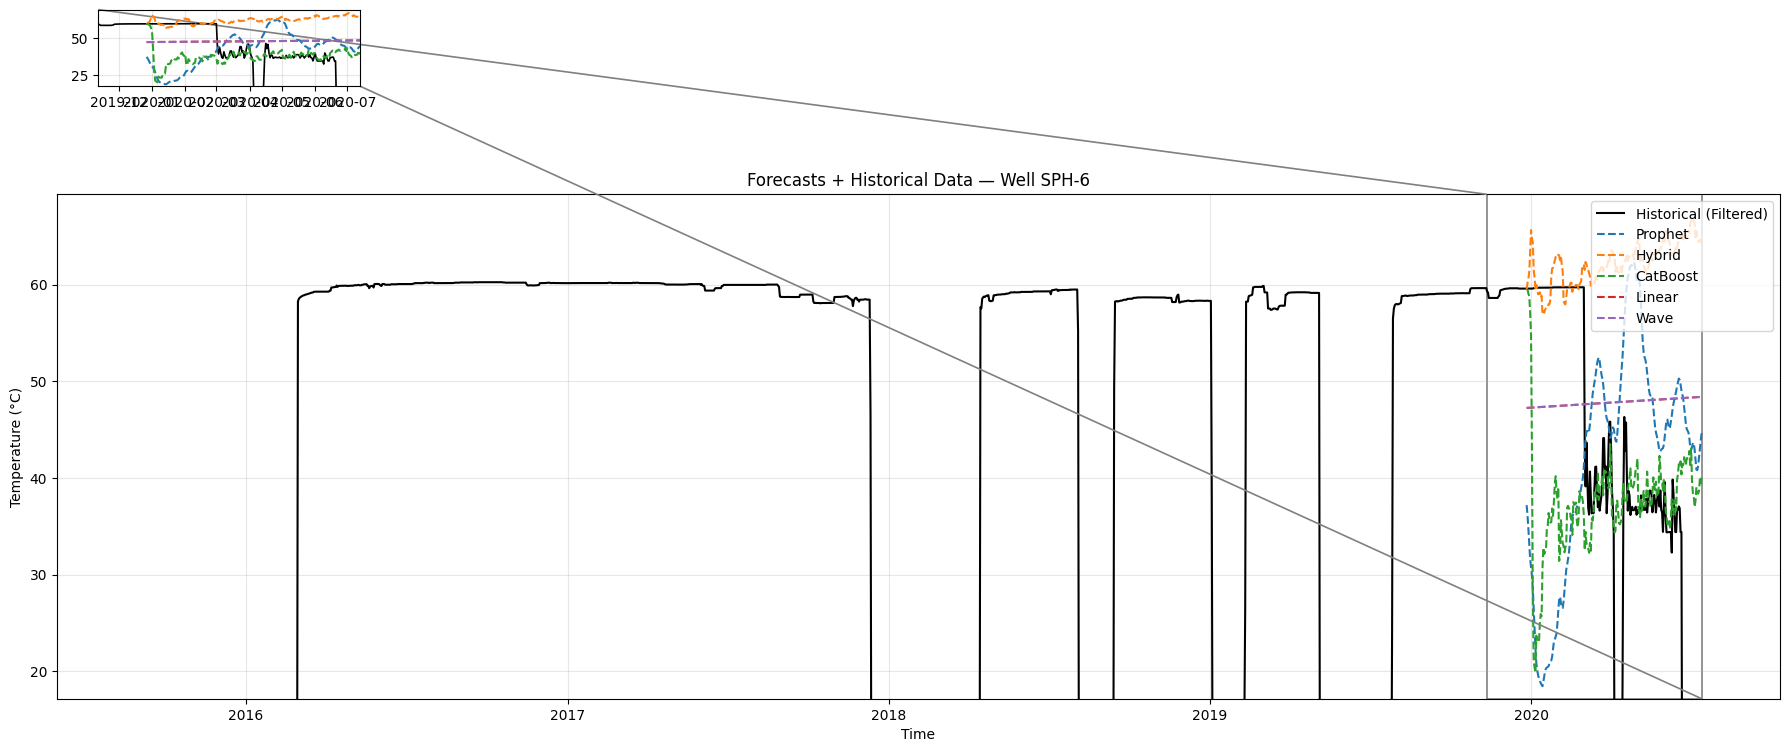

🕒 Well SPH-6 completed in 101.38 s

✅ PROCESSING FINISHED


,well,n_train,n_test,Prophet_MAE,Prophet_RMSE,Prophet_MAPE,Hybrid_MAE,Hybrid_RMSE,Hybrid_MAPE,CatBoost_MAE,...,Wave_MAE,Wave_RMSE,Wave_MAPE,y_true,yhat_prophet,yhat_hybrid,yhat_cat,yhat_linear,yhat_wave,test_dates
0,SPH-8,1668,200,39.548606,46.162509,1098.448750,29.032041,38.563626,933.209450,23.178873,...,26.025241,30.240587,723.772638,"[52.74380422769231, 52.719908366666665, 52.746...","[62.97930021898949, 64.21146211104686, 65.3570...","[53.78419878934708, 54.57601527585808, 54.8578...","[52.75155475860219, 52.65044540786917, 52.7105...","[43.74085447552814, 43.73698911181996, 43.7331...","[43.717623334701734, 43.71371571332942, 43.709...","[2019-12-04 00:00:00, 2019-12-05 00:00:00, 201..."
1,SPH-2,1627,200,27.538236,35.359097,770.719223,29.618683,40.130891,921.468136,24.978974,...,26.111711,33.166992,758.159213,"[57.17254704715907, 57.1712977333333, 57.17948...","[55.84265129633825, 55.653839313366674, 55.079...","[57.4997516710333, 57.25094041541599, 57.68040...","[56.84515104761321, 56.65120342919636, 51.3343...","[49.681961635772474, 49.690398608361235, 49.69...","[49.72447445113589, 49.732990454677505, 49.741...","[2019-12-09 00:00:00, 2019-12-10 00:00:00, 201..."
2,LL-11,2328,259,32.274539,35.606423,59.950279,18.228989,19.191638,33.865944,33.160321,...,37.733438,37.748865,70.150674,"[53.615917110000005, 53.5855927475, 53.5768093...","[26.848419486785907, 26.83275880510169, 26.382...","[54.54371955048567, 54.65805891599006, 54.3417...","[53.534517420698634, 53.640763072844805, 53.38...","[17.73054199784005, 17.718017538463847, 17.705...","[17.676797529410543, 17.66420317932405, 17.651...","[2019-10-08 00:00:00, 2019-10-09 00:00:00, 201..."
3,LL-22,2033,226,10.525748,16.801832,139.455777,5.127879,14.556566,124.819928,11.255304,...,7.520112,14.031616,121.930259,"[52.83878564999999, 52.830605415, 52.826758575...","[48.54587878532861, 48.05132449026635, 47.7218...","[52.09418675580073, 52.993346661599155, 52.802...","[52.90877995337787, 48.97224738642186, 52.5097...","[48.871755344154565, 48.87099282057223, 48.870...","[48.88512703097163, 48.88438434166409, 48.8836...","[2019-12-01 00:00:00, 2019-12-02 00:00:00, 201..."
4,SPS-77,2092,233,8.986986,13.741819,47.191936,6.062404,15.910580,48.859197,14.976811,...,9.278846,12.773369,44.797218,"[57.7344601575, 57.8563552775, 57.9054856275, ...","[56.6945094118182, 56.445789177616454, 56.2339...","[56.27385272941092, 56.20696574712074, 55.9879...","[57.01186381360443, 55.161065624704314, 47.440...","[45.53644740344577, 45.53659067287308, 45.5367...","[45.543707273288604, 45.54386173624588, 45.544...","[2019-11-05 00:00:00, 2019-11-06 00:00:00, 201..."
5,SPH-6,1582,200,23.671261,27.340466,1085.394209,23.320173,31.027932,1585.456886,15.324808,...,16.701577,21.426523,1170.748413,"[59.575645450000025, 59.575645450000025, 59.57...","[37.18425731704073, 36.086949507155865, 34.702...","[59.50493314390441, 60.17229644745956, 60.6143...","[59.55682460668061, 59.471942604309696, 59.082...","[47.24137672635455, 47.2471166622545, 47.25285...","[47.241740803743035, 47.24748105934061, 47.253...","[2019-12-27 00:00:00, 2019-12-28 00:00:00, 201..."


In [ ]:

# 9) LOOP PRINCIPAL + PLOT + INSET NO CANTO SUPERIOR ESQUERDO (DENTRO DO GRÁFICO)

print("\n" + "="*60)
print("🚀 STARTING WELL PROCESSING")
print("="*60)

csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

result_rows = []

for idx, path in enumerate(csv_files, start=1):
    well_name = os.path.splitext(os.path.basename(path))[0]
    print(f"\n{'-'*60}")
    print(f"🔹 [{idx}/{len(csv_files)}] Processing well: {well_name}")
    t_well = time.time()

    try:
        df = carregar_serie(
            filepath=path,
            col_tempo=COLUNA_TEMPO,
            col_valor=PARAMETRO_ALVO,
            do_resample=RESAMPLE,
            freq=FREQUENCIA,
            agg=RESAMPLE_AGG
        )

        if len(df) < 300:
            print(f"[Warn] Series too short ({len(df)}) for {well_name}. Skipping.")
            continue

        print(f"📈 Loaded series ({len(df)} points). Splitting train/test...")
        train_df, test_df = split_train_test(df, TRAIN_SPLIT, TEST_MIN_STEPS)

        # ---------- Run models ----------
        print("⚙️  Running model 1/5 → Prophet...")
        t0 = time.time()
        yhat_prophet = fit_forecast_prophet(train_df, test_df)
        print(f"✅ Prophet completed in {time.time()-t0:.2f} s")

        print("⚙️  Running model 2/5 → Hybrid (Prophet+LGBM)...")
        t0 = time.time()
        yhat_hybrid = fit_forecast_prophet_lgbm(train_df, test_df)
        print(f"✅ Hybrid completed in {time.time()-t0:.2f} s")

        print("⚙️  Running model 3/5 → CatBoost...")
        t0 = time.time()
        yhat_cat = fit_forecast_catboost(train_df, test_df)
        print(f"✅ CatBoost completed in {time.time()-t0:.2f} s")

        print("⚙️  Running model 4/5 → Linear...")
        t0 = time.time()
        yhat_linear = fit_forecast_linear(train_df, test_df)
        print(f"✅ Linear completed in {time.time()-t0:.2f} s")

        print("⚙️  Running model 5/5 → Wave...")
        t0 = time.time()
        yhat_wave = fit_forecast_wave(train_df, test_df)
        print(f"✅ Wave completed in {time.time()-t0:.2f} s")

        # ---------- Plot with robust zoom ----------
        fig, ax = plt.subplots(figsize=(18, 6))

        xmin = test_df["ds"].min()
        xmax = test_df["ds"].max()

        y_test_all = np.concatenate([
            test_df["y"].values,
            np.array(yhat_prophet),
            np.array(yhat_hybrid),
            np.array(yhat_cat),
            np.array(yhat_linear),
            np.array(yhat_wave),
        ])

        q_low, q_high = np.nanquantile(y_test_all, [0.05, 0.95])
        y_margin = 0.15 * (q_high - q_low) if q_high > q_low else 1.0
        y_main_min = q_low - y_margin
        y_main_max = q_high + y_margin

        # Main plot (English)
        ax.plot(df["ds"], df["y"], color="black", linewidth=1.5, label="Historical (Filtered)")
        ax.plot(test_df["ds"], yhat_prophet, "--", label="Prophet")
        ax.plot(test_df["ds"], yhat_hybrid, "--", label="Hybrid")
        ax.plot(test_df["ds"], yhat_cat, "--", label="CatBoost")
        ax.plot(test_df["ds"], yhat_linear, "--", label="Linear")
        ax.plot(test_df["ds"], yhat_wave, "--", label="Wave")

        ax.set_title(f"Forecasts + Historical Data — Well {well_name}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Temperature (°C)")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right")
        ax.set_ylim(y_main_min, y_main_max)

        # Inset INSIDE the plot, upper-left
        axins = inset_axes(
            ax,
            width="38%", height="38%",
            loc="upper left",
            bbox_to_anchor=(0.02, 0.98, 0.40, 0.40),  # stays inside
            bbox_transform=ax.transAxes,
            borderpad=0.5
        )

        x_zoom_days = 45
        xmin_zoom = xmin - pd.Timedelta(days=x_zoom_days)
        df_zoom = df[df["ds"] >= xmin_zoom]

        axins.plot(df_zoom["ds"], df_zoom["y"], color="black", linewidth=1.2)
        axins.plot(test_df["ds"], yhat_prophet, "--")
        axins.plot(test_df["ds"], yhat_hybrid, "--")
        axins.plot(test_df["ds"], yhat_cat, "--")
        axins.plot(test_df["ds"], yhat_linear, "--")
        axins.plot(test_df["ds"], yhat_wave, "--")

        axins.set_xlim(xmin_zoom, xmax)
        axins.set_ylim(y_main_min, y_main_max)
        axins.grid(alpha=0.3)

        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray", lw=1.2)

        plt.tight_layout()
        plt.show()

        # ---------- Evaluation ----------
        y_true = test_df["y"].values

        row = dict(
            well=well_name, n_train=len(train_df), n_test=len(test_df),

            Prophet_MAE=mean_absolute_error(y_true, yhat_prophet),
            Prophet_RMSE=rmse(y_true, yhat_prophet),
            Prophet_MAPE=mape(y_true, yhat_prophet),

            Hybrid_MAE=mean_absolute_error(y_true, yhat_hybrid),
            Hybrid_RMSE=rmse(y_true, yhat_hybrid),
            Hybrid_MAPE=mape(y_true, yhat_hybrid),

            CatBoost_MAE=mean_absolute_error(y_true, yhat_cat),
            CatBoost_RMSE=rmse(y_true, yhat_cat),
            CatBoost_MAPE=mape(y_true, yhat_cat),

            Linear_MAE=mean_absolute_error(y_true, yhat_linear),
            Linear_RMSE=rmse(y_true, yhat_linear),
            Linear_MAPE=mape(y_true, yhat_linear),

            Wave_MAE=mean_absolute_error(y_true, yhat_wave),
            Wave_RMSE=rmse(y_true, yhat_wave),
            Wave_MAPE=mape(y_true, yhat_wave),

            y_true=list(y_true),
            yhat_prophet=list(yhat_prophet),
            yhat_hybrid=list(yhat_hybrid),
            yhat_cat=list(yhat_cat),
            yhat_linear=list(yhat_linear),
            yhat_wave=list(yhat_wave),
            test_dates=list(test_df["ds"])
        )
        result_rows.append(row)

        print(f"🕒 Well {well_name} completed in {time.time()-t_well:.2f} s")

    except Exception as e:
        print(f"[❌ Error] {well_name}: {e}")

    finally:
        for var in ["df","train_df","test_df","yhat_prophet","yhat_hybrid","yhat_cat","yhat_linear","yhat_wave"]:
            if var in locals():
                del locals()[var]
        gc.collect()

print("\n" + "="*60)
print("✅ PROCESSING FINISHED")
print("="*60)

results = pd.DataFrame(result_rows)
if len(results) > 0:
    display(results)
    if SALVAR_RESULTADOS_CSV:
        results.to_csv(RESULTS_CSV_PATH, index=False)
        print(f"Saved to: {RESULTS_CSV_PATH}")


In [ ]:

# 10) SUMMARY TABLE (INGLÊS)

if len(results) == 0:
    print("No results to summarize.")
else:
    def fmt(x, dec=3):
        return f"{x:.{dec}f}" if pd.notna(x) else "-"

    print("\n" + "="*110)
    print("📊 METRICS SUMMARY PER WELL (5 MODELS)")
    print("="*110)
    print(f"{'Well':<18} "
          f"{'Prophet MAPE':<13} {'Hybrid MAPE':<12} {'CatBoost MAPE':<13} {'Linear MAPE':<12} {'Wave MAPE':<11} | "
          f"{'Prophet MAE':<13} {'Hybrid MAE':<12} {'CatBoost MAE':<13} {'Linear MAE':<12} {'Wave MAE':<11}")
    print("-"*110)

    for _, r in results.iterrows():
        print(f"{str(r['well']):<18} "
              f"{fmt(r.get('Prophet_MAPE'),2):<13} {fmt(r.get('Hybrid_MAPE'),2):<12} {fmt(r.get('CatBoost_MAPE'),2):<13} "
              f"{fmt(r.get('Linear_MAPE'),2):<12} {fmt(r.get('Wave_MAPE'),2):<11} | "
              f"{fmt(r.get('Prophet_MAE')):<13} {fmt(r.get('Hybrid_MAE')):<12} {fmt(r.get('CatBoost_MAE')):<13} "
              f"{fmt(r.get('Linear_MAE')):<12} {fmt(r.get('Wave_MAE')):<11}")

    print("="*110)

    # Averages
    avg_cols = ["Prophet_MAPE","Hybrid_MAPE","CatBoost_MAPE","Linear_MAPE","Wave_MAPE",
                "Prophet_MAE","Hybrid_MAE","CatBoost_MAE","Linear_MAE","Wave_MAE"]
    means = results[avg_cols].mean(numeric_only=True)

    print("\nAverages:")
    for c in avg_cols:
        dec = 2 if "MAPE" in c else 3
        print(f"  {c:<14}: {means[c]:.{dec}f}")



📊 METRICS SUMMARY PER WELL (5 MODELS)
Well               Prophet MAPE  Hybrid MAPE  CatBoost MAPE Linear MAPE  Wave MAPE   | Prophet MAE   Hybrid MAE   CatBoost MAE  Linear MAE   Wave MAE   
--------------------------------------------------------------------------------------------------------------
SPH-8              1098.45       933.21       657.15        724.27       723.77      | 39.549        29.032       23.179        26.030       26.025     
SPH-2              770.72        921.47       426.37        757.35       758.16      | 27.538        29.619       24.979        26.111       26.112     
LL-11              59.95         33.87        61.64         70.03        70.15       | 32.275        18.229       33.160        37.671       37.733     
LL-22              139.46        124.82       115.96        121.92       121.93      | 10.526        5.128        11.255        7.533        7.520      
SPS-77             47.19         48.86        48.26         44.80        44.80       


📊 COMPARATIVE VISUALIZATIONS — 5 MODELS (MAE)


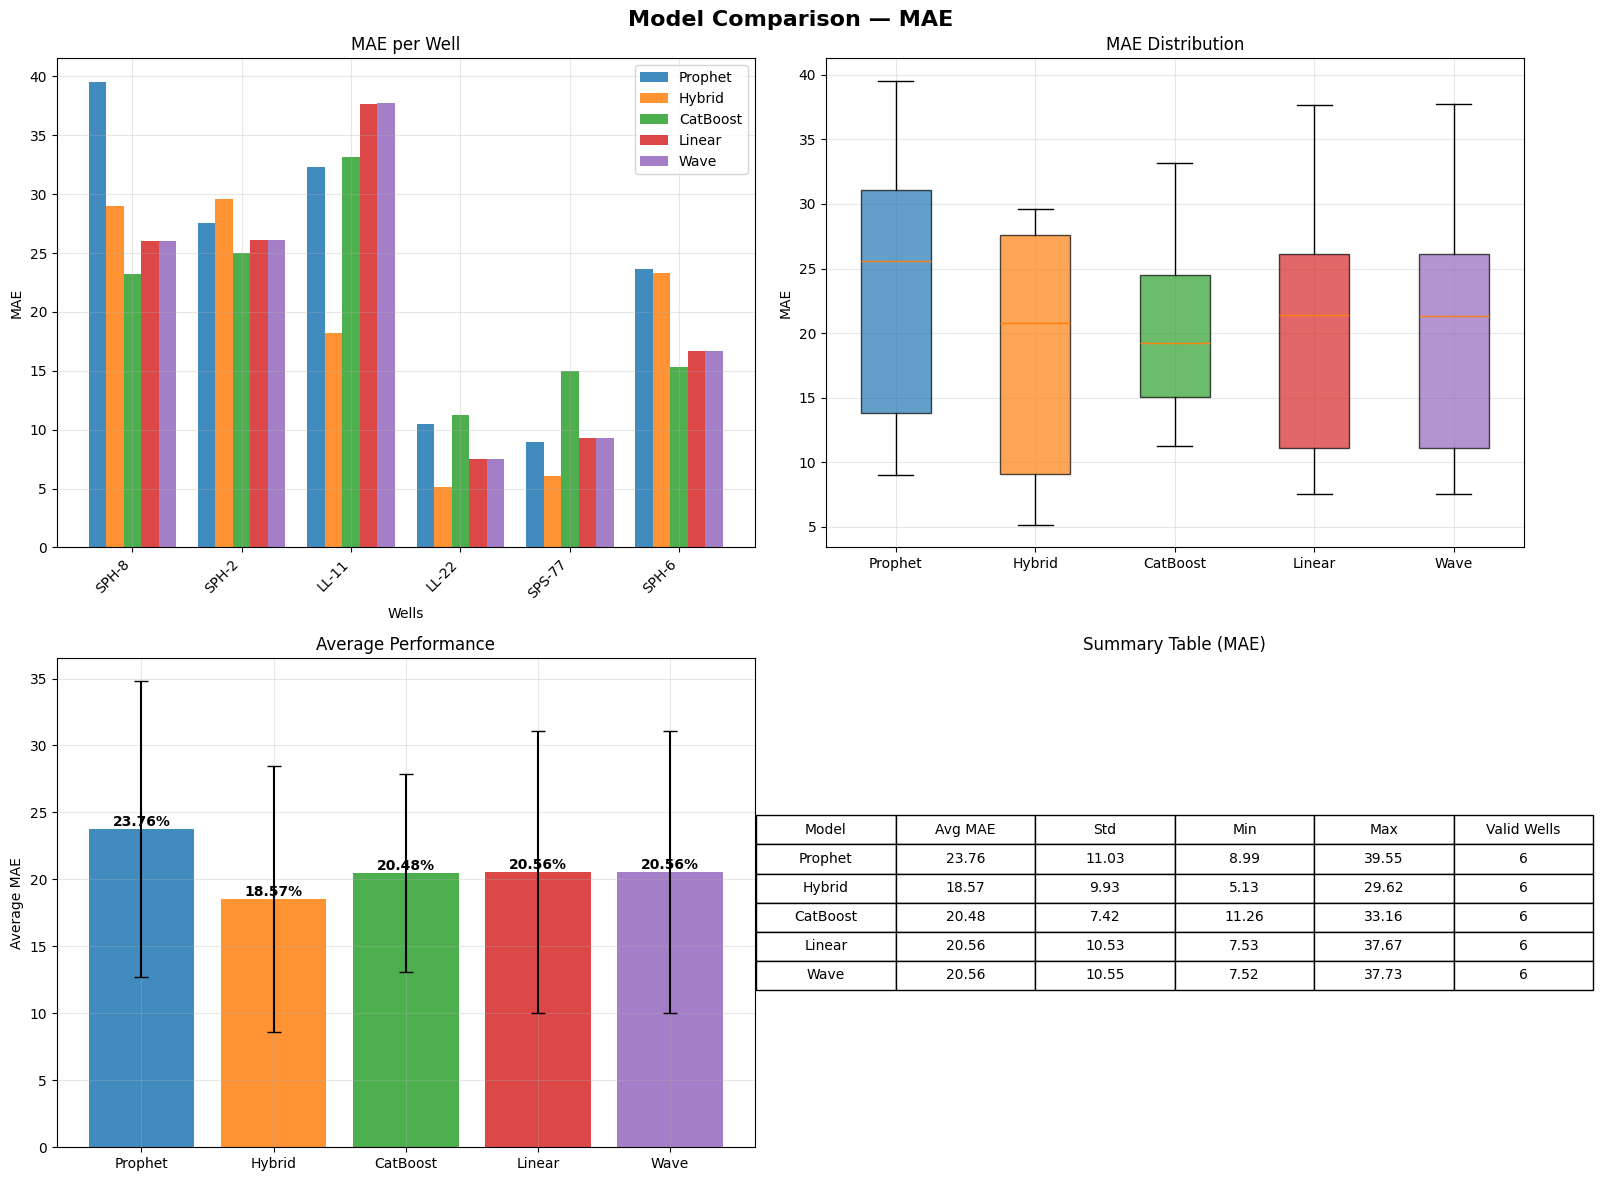

In [ ]:

# 11) COMPARATIVE PLOTS (MAE) — 5 MODELS (INGLÊS)

print("\n" + "="*80)
print("📊 COMPARATIVE VISUALIZATIONS — 5 MODELS (MAE)")
print("="*80)

colors = {
    "Prophet": "#1f77b4",
    "Hybrid": "#ff7f0e",
    "CatBoost": "#2ca02c",
    "Linear": "#d62728",
    "Wave": "#9467bd",
    "Observed": "black"
}

if len(results) == 0:
    print("No results to plot.")
else:
    # Dict
    results_dict = {}
    for _, row in results.iterrows():
        results_dict[row["well"]] = {
            "metrics": {
                "Prophet": row.get("Prophet_MAE", np.nan),
                "Hybrid": row.get("Hybrid_MAE", np.nan),
                "CatBoost": row.get("CatBoost_MAE", np.nan),
                "Linear": row.get("Linear_MAE", np.nan),
                "Wave": row.get("Wave_MAE", np.nan),
            }
        }

    model_names = ["Prophet", "Hybrid", "CatBoost", "Linear", "Wave"]
    well_names = list(results_dict.keys())
    x = np.arange(len(well_names))
    width = 0.16

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Model Comparison — MAE ", fontsize=16, fontweight="bold")

    # 1) Bar by well
    for i, m in enumerate(model_names):
        vals = [results_dict[w]["metrics"][m] for w in well_names]
        ax1.bar(x + i*width, vals, width, label=m, color=colors[m], alpha=0.85)

    ax1.set_xlabel("Wells")
    ax1.set_ylabel("MAE")
    ax1.set_title("MAE per Well")
    ax1.set_xticks(x + width*2)
    ax1.set_xticklabels(well_names, rotation=45, ha="right")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # 2) Boxplot
    data = []
    labels = []
    for m in model_names:
        arr = [results_dict[w]["metrics"][m] for w in well_names]
        arr = [v for v in arr if np.isfinite(v)]
        if arr:
            data.append(arr)
            labels.append(m)

    if data:
        bp = ax2.boxplot(data, labels=labels, patch_artist=True)
        for patch, m in zip(bp["boxes"], labels):
            patch.set_facecolor(colors[m])
            patch.set_alpha(0.7)

    ax2.set_ylabel("MAE")
    ax2.set_title("MAE Distribution")
    ax2.grid(True, alpha=0.3)

    # 3) Means
    means = {m: np.nanmean([results_dict[w]["metrics"][m] for w in well_names]) for m in model_names}
    stds  = {m: np.nanstd([results_dict[w]["metrics"][m] for w in well_names]) for m in model_names}

    ms = [m for m in model_names if np.isfinite(means[m])]
    mean_vals = [means[m] for m in ms]
    std_vals  = [stds[m] for m in ms]

    bars = ax3.bar(ms, mean_vals, yerr=std_vals, capsize=5, color=[colors[m] for m in ms], alpha=0.85)
    for bar, v in zip(bars, mean_vals):
        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")

    ax3.set_ylabel("Average MAE")
    ax3.set_title("Average Performance")
    ax3.grid(True, alpha=0.3)

    # 4) Table
    ax4.axis("off")
    headers = ["Model", "Avg MAE", "Std", "Min", "Max", "Valid Wells"]
    table_data = []
    for m in model_names:
        vals = [results_dict[w]["metrics"][m] for w in well_names]
        vals = np.array([v for v in vals if np.isfinite(v)])
        if len(vals) > 0:
            table_data.append([
                m,
                f"{vals.mean():.2f}",
                f"{vals.std():.2f}",
                f"{vals.min():.2f}",
                f"{vals.max():.2f}",
                f"{len(vals)}"
            ])

    if table_data:
        table = ax4.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)

    ax4.set_title("Summary Table (MAE)")

    plt.tight_layout()
    plt.show()


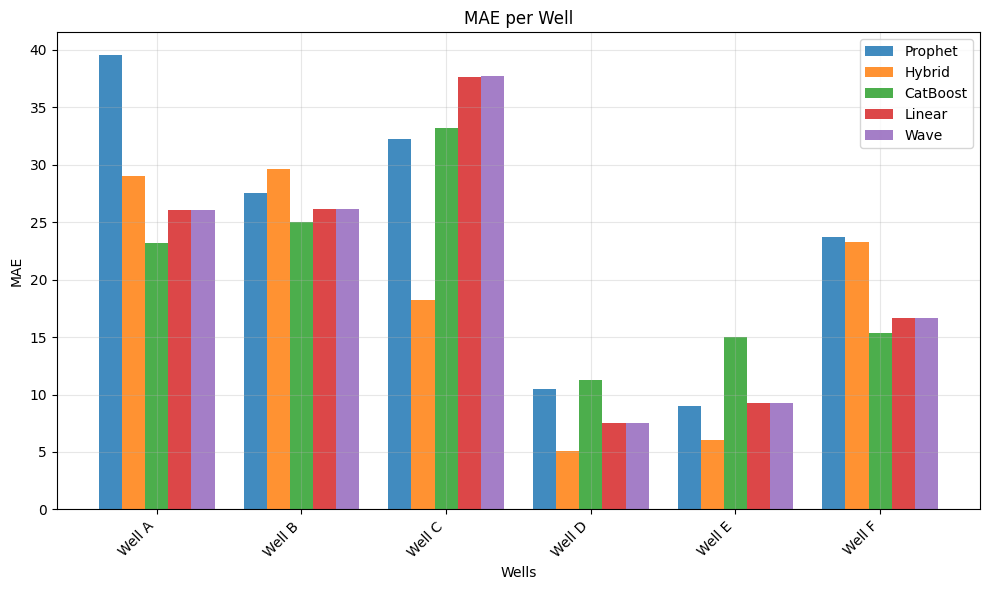

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

colors = {
    "Prophet": "#1f77b4",
    "Hybrid": "#ff7f0e",
    "CatBoost": "#2ca02c",
    "Linear": "#d62728",
    "Wave": "#9467bd",
}

if len(results) == 0:
    print("No results to plot.")
else:
    # Criar dicionário de resultados
    results_dict = {}
    for _, row in results.iterrows():
        results_dict[row["well"]] = {
            "metrics": {
                "Prophet": row.get("Prophet_MAE", np.nan),
                "Hybrid": row.get("Hybrid_MAE", np.nan),
                "CatBoost": row.get("CatBoost_MAE", np.nan),
                "Linear": row.get("Linear_MAE", np.nan),
                "Wave": row.get("Wave_MAE", np.nan),
            }
        }

    model_names = ["Prophet", "Hybrid", "CatBoost", "Linear", "Wave"]
    well_names = list(results_dict.keys())
    x = np.arange(len(well_names))
    width = 0.16

    # Criar labels genéricos: well a, well b, well c...
    custom_labels = [f"Well {chr(65+i)}" for i in range(len(well_names))]

    # Apenas o gráfico MAE per Well
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, m in enumerate(model_names):
        vals = [results_dict[w]["metrics"][m] for w in well_names]
        ax.bar(x + i*width, vals, width, label=m, color=colors[m], alpha=0.85)

    ax.set_xlabel("Wells")
    ax.set_ylabel("MAE")
    ax.set_title("MAE per Well")
    ax.set_xticks(x + width*2)
    ax.set_xticklabels(custom_labels, rotation=45, ha="right")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()



📊 Individual plots for the first 3 wells...


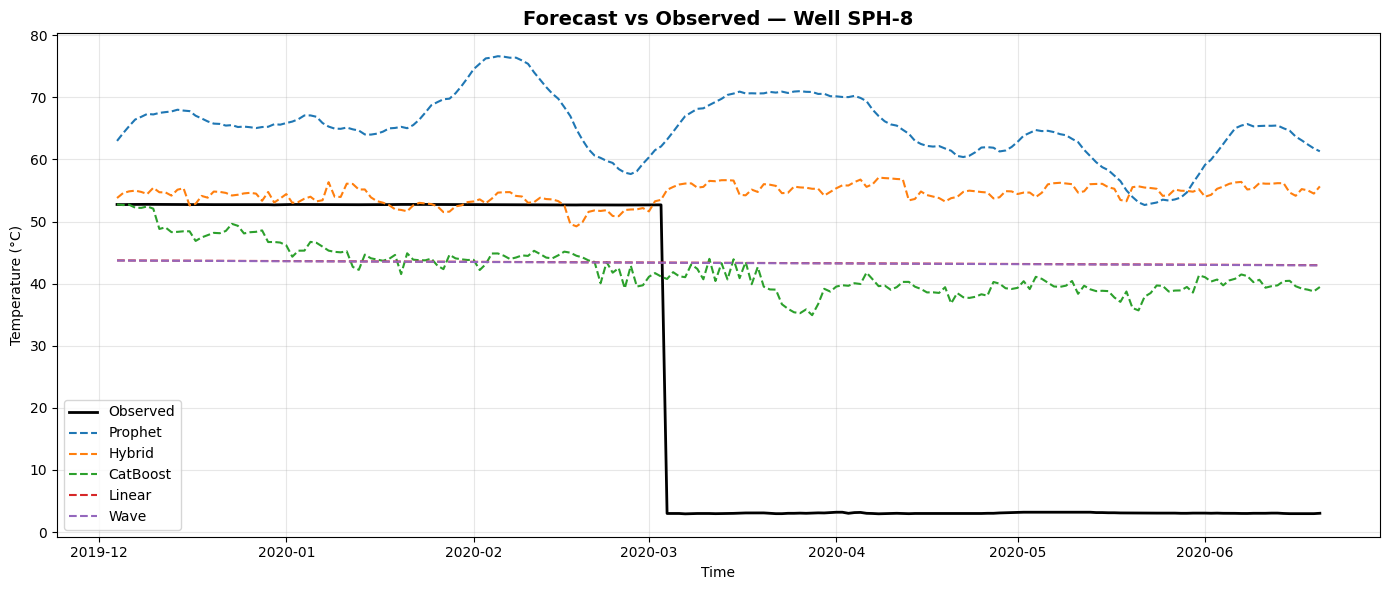

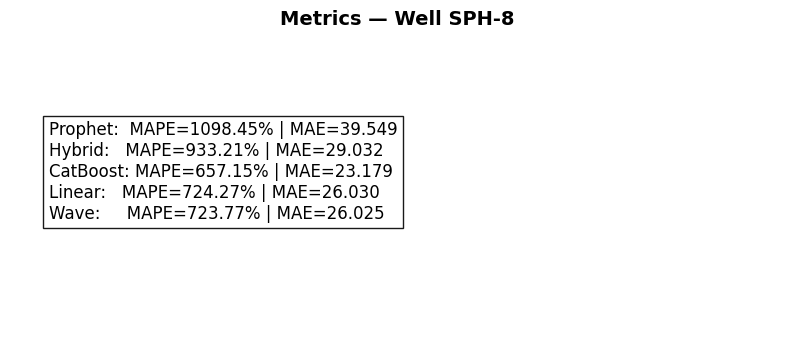

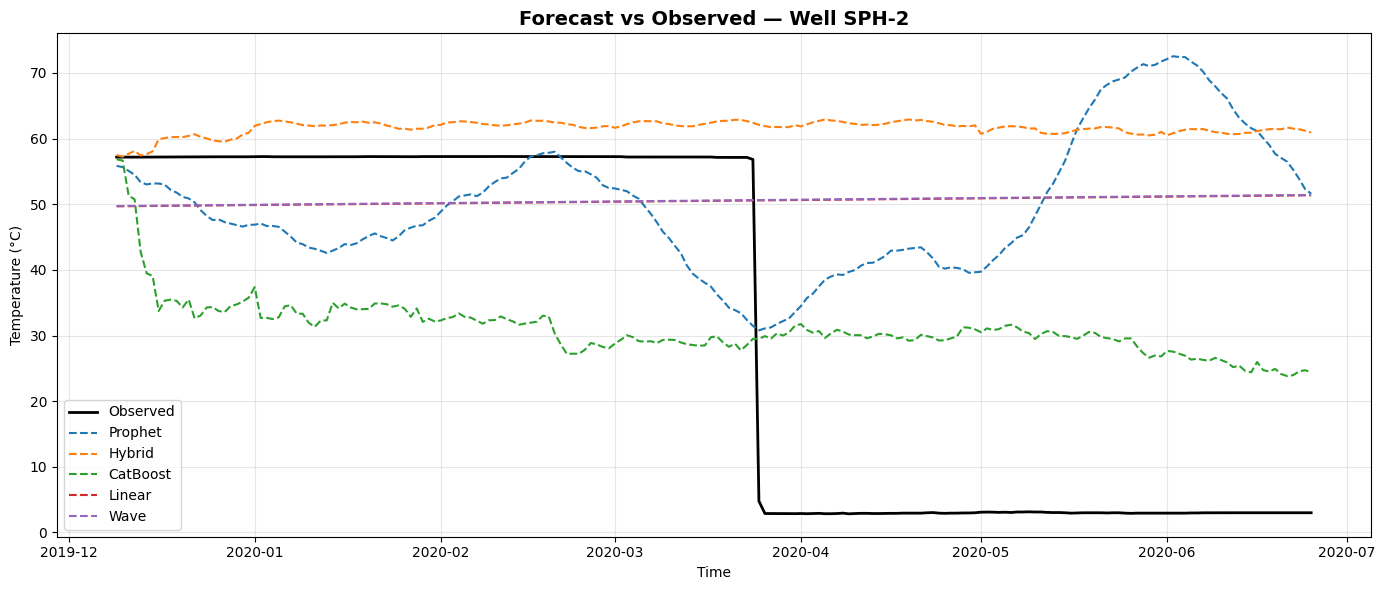

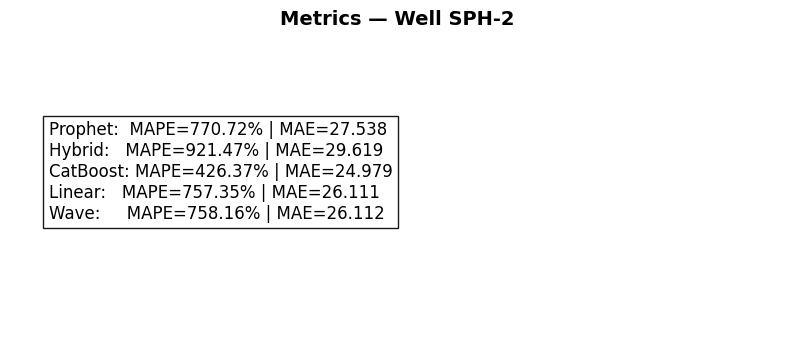

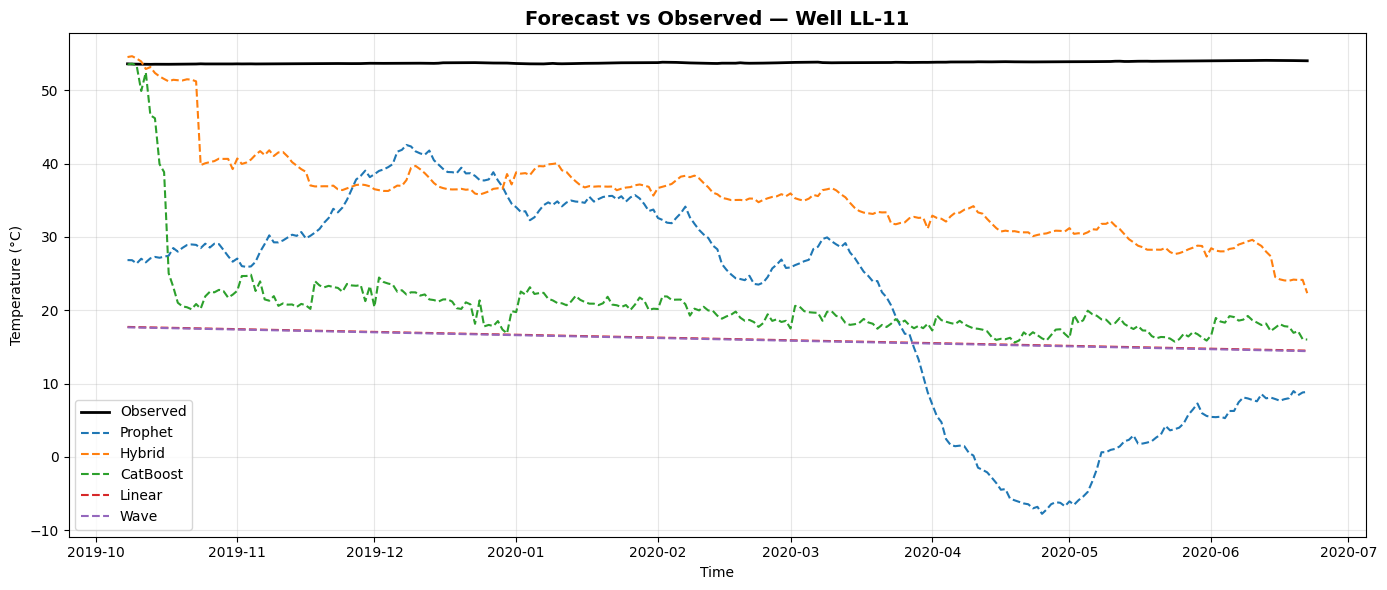

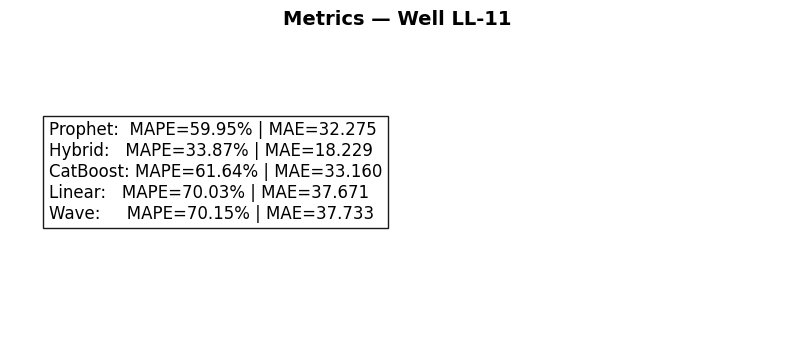

In [ ]:

# 12) INDIVIDUAL PLOTS (FIRST 3 WELLS) — ENGLISH + METRICS BOX

if len(results) == 0:
    print("No results to plot.")
else:
    print("\n📊 Individual plots for the first 3 wells...")

    for i, (_, row) in enumerate(results.iterrows()):
        if i >= 3:
            break

        well_name = row["well"]
        dates = row["test_dates"]
        y_true = row["y_true"]

        plt.figure(figsize=(14, 6))
        plt.plot(dates, y_true, color=colors["Observed"], label="Observed", linewidth=2)

        plt.plot(dates, row["yhat_prophet"], "--", label="Prophet", color=colors["Prophet"])
        plt.plot(dates, row["yhat_hybrid"],  "--", label="Hybrid",  color=colors["Hybrid"])
        plt.plot(dates, row["yhat_cat"],     "--", label="CatBoost", color=colors["CatBoost"])
        plt.plot(dates, row["yhat_linear"],  "--", label="Linear",  color=colors["Linear"])
        plt.plot(dates, row["yhat_wave"],    "--", label="Wave",    color=colors["Wave"])

        plt.title(f"Forecast vs Observed — Well {well_name}", fontsize=14, fontweight="bold")
        plt.xlabel("Time")
        plt.ylabel("Temperature (°C)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        metrics_text = (
            f"Prophet:  MAPE={row['Prophet_MAPE']:.2f}% | MAE={row['Prophet_MAE']:.3f}\n"
            f"Hybrid:   MAPE={row['Hybrid_MAPE']:.2f}% | MAE={row['Hybrid_MAE']:.3f}\n"
            f"CatBoost: MAPE={row['CatBoost_MAPE']:.2f}% | MAE={row['CatBoost_MAE']:.3f}\n"
            f"Linear:   MAPE={row['Linear_MAPE']:.2f}% | MAE={row['Linear_MAE']:.3f}\n"
            f"Wave:     MAPE={row['Wave_MAPE']:.2f}% | MAE={row['Wave_MAE']:.3f}"
        )

        plt.figure(figsize=(10, 4))
        plt.axis("off")
        plt.text(0.05, 0.55, metrics_text, fontsize=12,
                 bbox=dict(facecolor="white", alpha=0.9),
                 va="center", transform=plt.gca().transAxes)
        plt.title(f"Metrics — Well {well_name}", fontsize=14, fontweight="bold")
        plt.show()
